# Decision Tree and Random Forest

In [1]:
#Import dataset
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [5]:
# Load Dataset
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
# Check Dataset
print(df.info())
print(df.isnull().sum())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
  

In [7]:
# Features and Target
X = df.drop("target", axis=1)
y = df["target"]

In [8]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [10]:
# Prediction and Accuracy
y_pred = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))

Decision Tree Accuracy: 0.9853658536585366


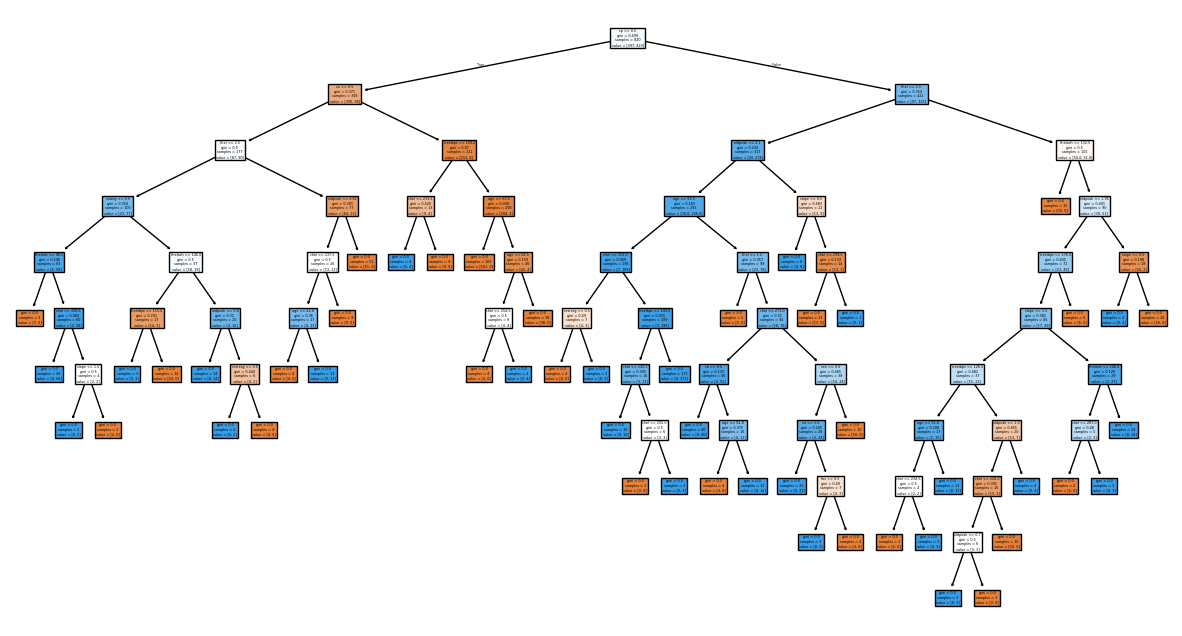

In [11]:
# Visualize Decision Tree
plt.figure(figsize=(15,8))
plot_tree(dt, feature_names=X.columns, filled=True)
plt.show()

In [12]:
# Check Overfitting
train_acc = accuracy_score(y_train, dt.predict(X_train))
test_acc = accuracy_score(y_test, dt.predict(X_test))
print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 1.0
Testing Accuracy: 0.9853658536585366


In [13]:
# Control Overfitting
dt2 = DecisionTreeClassifier(max_depth=4, random_state=42)
dt2.fit(X_train, y_train)
pred2 = dt2.predict(X_test)
print("Pruned Tree Accuracy:", accuracy_score(y_test, pred2))

Pruned Tree Accuracy: 0.8


In [14]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9853658536585366


     Feature  Importance
2         cp    0.134791
11        ca    0.127149
7    thalach    0.122002
9    oldpeak    0.121119
12      thal    0.110847
0        age    0.077912
4       chol    0.075145
3   trestbps    0.071376
8      exang    0.057739
10     slope    0.046353
1        sex    0.028902
6    restecg    0.018385
5        fbs    0.008280


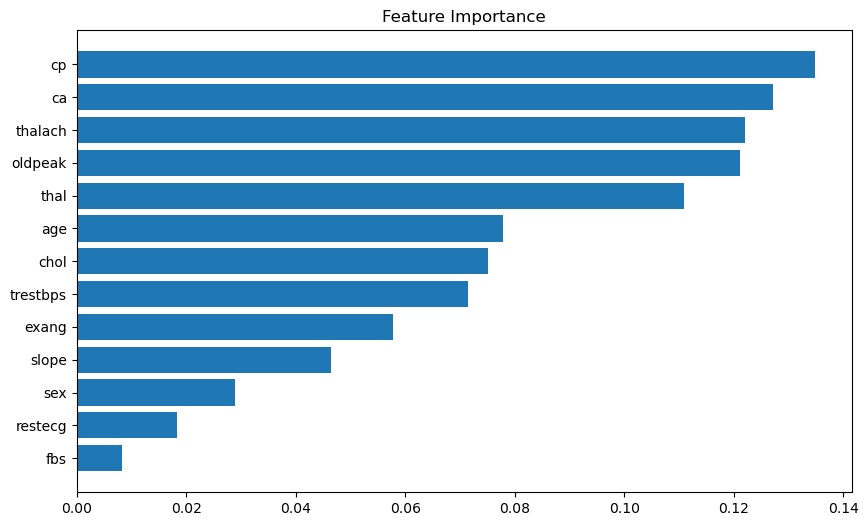

In [15]:
# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance)

plt.figure(figsize=(10,6))
plt.barh(importance["Feature"], importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

In [16]:
# Cross Validation
scores = cross_val_score(rf, X, y, cv=5)
print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())

Cross Validation Scores: [1.         1.         1.         1.         0.98536585]
Average Accuracy: 0.9970731707317073
